In [2]:
'''
GRAPPA reconstruction with an iterative algorithm from CIL: illustrates
the use of AcquisitionModel in CIL optimisation 

Usage:
  grappa_and_cil.py [--help | options]

Options:
  -f <file>, --file=<file>    raw data file
                              [default: simulated_MR_2D_cartesian_Grappa2.h5]
  -p <path>, --path=<path>    path to data files, defaults to data/examples/MR
                              subfolder of SIRF root folder
'''

## CCP PETMR Synergistic Image Reconstruction Framework (SIRF)
## Copyright 2015 - 2019 Rutherford Appleton Laboratory STFC.
## Copyright 2015 - 2019 University College London.
##
## This is software developed for the Collaborative Computational
## Project in Positron Emission Tomography and Magnetic Resonance imaging
## (http://www.ccppetmr.ac.uk/).
##
## Licensed under the Apache License, Version 2.0 (the "License");
##   you may not use this file except in compliance with the License.
##   You may obtain a copy of the License at
##       http://www.apache.org/licenses/LICENSE-2.0
##   Unless required by applicable law or agreed to in writing, software
##   distributed under the License is distributed on an "AS IS" BASIS,
##   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
##   See the License for the specific language governing permissions and
##   limitations under the License.
    

import sirf
from sirf.Utilities import existing_filepath
from sirf.Utilities import error
from sirf.Utilities import show_3D_array
from sirf.Gadgetron import examples_data_path
from sirf.Gadgetron import AcquisitionData, ImageData
from sirf.Gadgetron import AcquisitionModel
from sirf.Gadgetron import AcquisitionDataProcessor
from sirf.Gadgetron import CartesianGRAPPAReconstructor, FullySampledReconstructor
from sirf.Gadgetron import CoilSensitivityData
from sirf.Gadgetron import preprocess_acquisition_data

from cil.optimisation.functions import LeastSquares
from cil.optimisation.functions import ZeroFunction
from cil.optimisation.algorithms import FISTA, CGLS, GD
from cil.plugins.ccpi_regularisation.functions import FGP_TV#, TGV, LLT_ROF, Diff4th
from cil.framework import DataContainer as cilDataContainer
from cil.optimisation.operators import LinearOperator

import numpy
import time
# %matplotlib notebook
import matplotlib.pyplot as plt
import os


In [3]:
# process command-line options
fname_ai = '1meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL_mod.h5'
fname_full = '1meas_MID00614_FID129152_CONVENTIONAL_RECON_SEQD_GF2_AX_RL_mod.h5'

data_path = '/home/jovyan/work/data/h5'

input_file = os.path.join(data_path, fname_full)
print (input_file)
# acquisition data will be read from an HDF file input_data
acq_data_full = AcquisitionData(input_file)

/home/jovyan/work/data/h5/1meas_MID00614_FID129152_CONVENTIONAL_RECON_SEQD_GF2_AX_RL_mod.h5
reading from /home/jovyan/work/data/h5/1meas_MID00614_FID129152_CONVENTIONAL_RECON_SEQD_GF2_AX_RL_mod.h5 using ignore mask 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 

Started reading acquisitions from /home/jovyan/work/data/h5/1meas_MID00614_FID129152_CONVENTIONAL_RECON_SEQD_GF2_AX_RL_mod.h5
0%..10%..20%..31%..40%..50%..61%..70%..80%..90%..
Finished reading acquisitions from /home/jovyan/work/data/h5/1meas_MID00614_FID129152_CONVENTIONAL_RECON_SEQD_GF2_AX_RL_mod.h5


In [4]:
acq_data = preprocess_acquisition_data(acq_data_full)

Message received with ID: 5
Input stream has terminated


In [5]:
recon = FullySampledReconstructor()
recon.set_input(acq_data)
recon.process()


Message received with ID: 5
Input stream has terminated


In [6]:
from cil.utilities.display import show2D
from cil.utilities.jupyter import islicer
import numpy as np

full_recon = np.abs(recon.get_output().asarray(), dtype=np.float32)

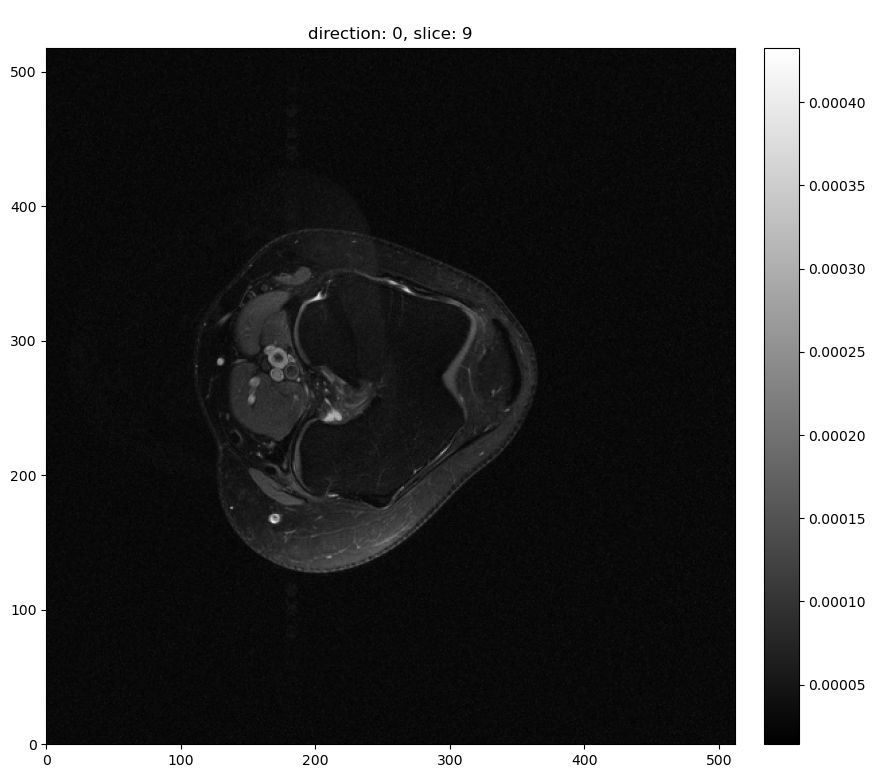

In [7]:
show2D(full_recon)

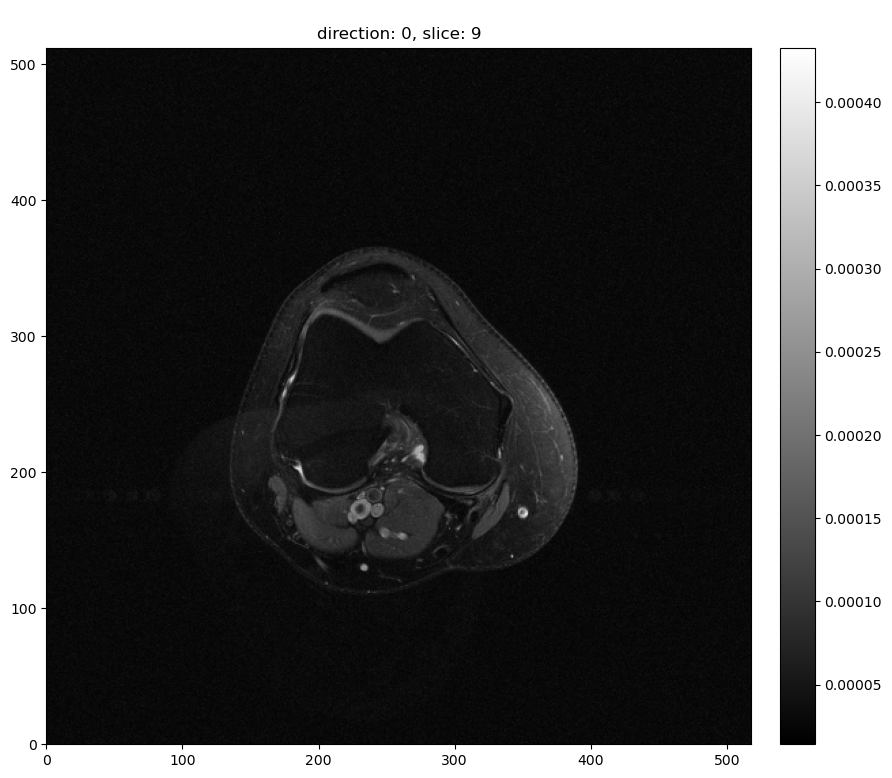

In [11]:
# ER rotate images for powerpoint
full_recon_rotated = np.rot90(full_recon, axes=(2, 1))
show2D(full_recon_rotated)

In [7]:
print(type(full_recon), full_recon.dtype)

<class 'numpy.ndarray'> float32


In [12]:
# downsampled data
input_file = os.path.join(data_path, fname_ai)
acq_data_ai = AcquisitionData(input_file)
acq_data_ai = preprocess_acquisition_data(acq_data_ai)

reading from /home/jovyan/work/data/h5/1meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL_mod.h5 using ignore mask 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 

Started reading acquisitions from /home/jovyan/work/data/h5/1meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL_mod.h5
0%..10%..20%..30%..40%..50%..60%..70%..80%..90%..100%..
Finished reading acquisitions from /home/jovyan/work/data/h5/1meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL_mod.h5
ignoring acquisition 0
Message received with ID: 5
Input stream has terminated


In [13]:
csm = CoilSensitivityData()
csm.smoothness = 100
csm.calculate(acq_data_ai)

In [14]:
E = AcquisitionModel(acqs=acq_data_ai, imgs=csm)
E.set_coil_sensitivity_maps(csm)
x_inverse = E.inverse(acq_data_ai)

In [15]:
# create acquisition model based on the acquisition parameters
# stored in preprocessed_data and image parameters stored in
# image_data
E = AcquisitionModel(acqs=acq_data_ai, imgs=x_inverse)
E.set_coil_sensitivity_maps(csm)


# Use the result of the inverse as our starting point
x_init = x_inverse.clone()

# Define our objective/loss function as least squares between Ex and y
f = LeastSquares(E, acq_data_ai, c=1)

G = ZeroFunction()

# Set up FISTA
fista = FISTA(initial=x_init.fill(0.0), f=f, g=G)
fista.update_objective_interval = 5


# Run FISTA for least squares
fista.run(10)

  0%|          | 0/10 [00:00<?, ?it/s]

In [19]:
ai_recon = np.abs(fista.solution.asarray(), dtype=np.float32)

In [20]:
# normalise results
def normalise(data):
    return (data - data.min())/(data.max()-data.min())


fn_recon = normalise(full_recon)
ain_recon = normalise(ai_recon)

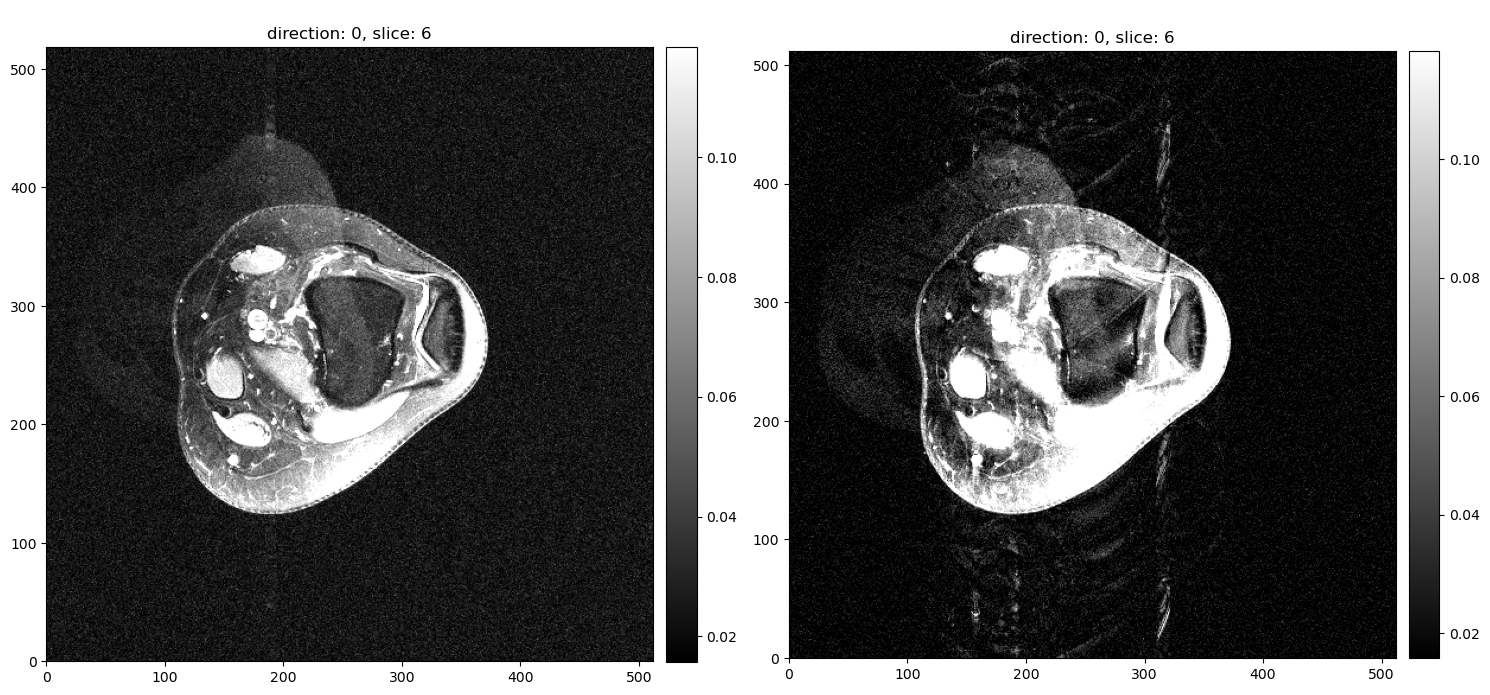

In [21]:
show2D([fn_recon, ain_recon], slice_list=(0, 6), fix_range=(np.percentile(fn_recon, 5), np.percentile(fn_recon, 95)))

In [22]:
 # ER rotate images for powerpoint
fn_recon_rotated = np.rot90(fn_recon, axes=(2, 1))
ain_recon_rotated = np.rot90(ain_recon, axes=(2, 1))

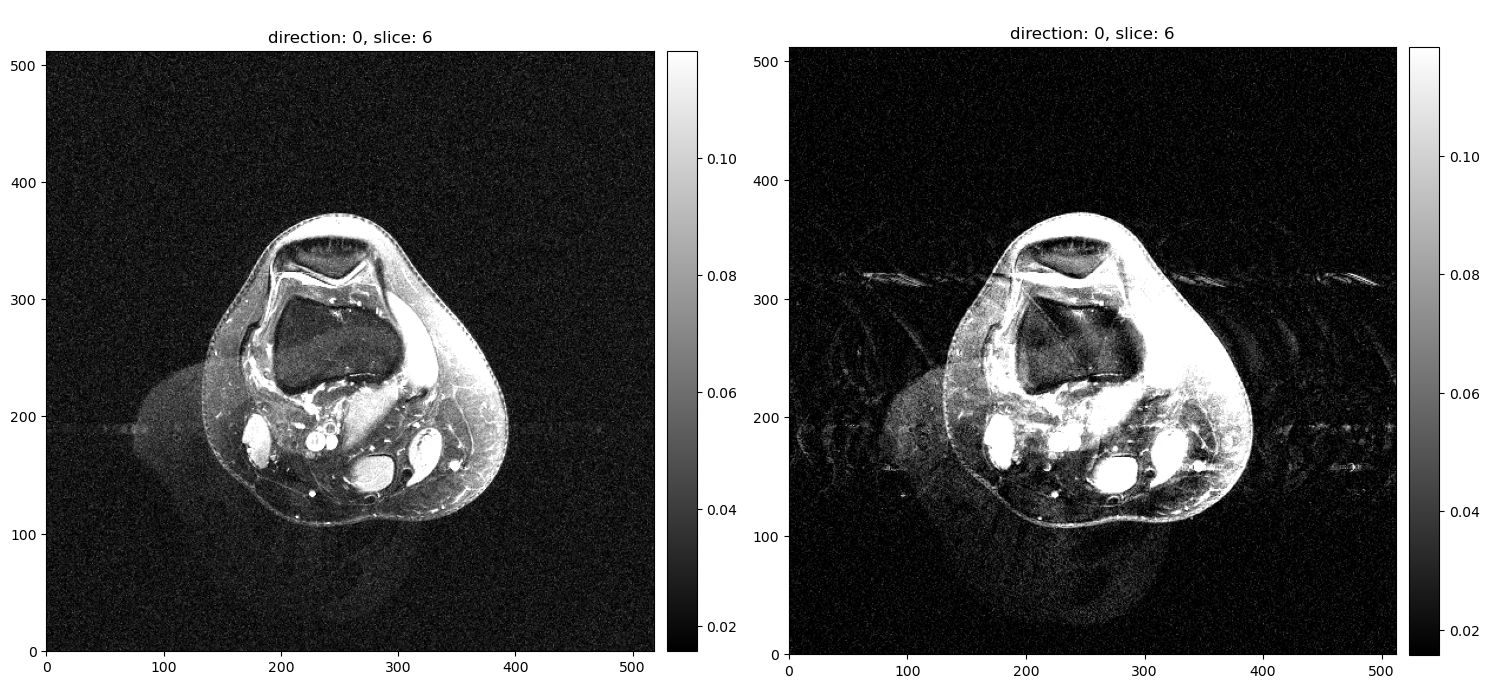

In [23]:
show2D([fn_recon_rotated, ain_recon_rotated], slice_list=(0, 6), fix_range=(np.percentile(fn_recon, 5), np.percentile(fn_recon, 95)))

In [24]:
from cil.optimisation.functions import L1Sparsity, FunctionOfAbs
from cil.optimisation.operators import WaveletOperator
from cil.plugins.ccpi_regularisation.functions import FGP_TV

TV = FGP_TV(alpha = 0.3)


/tmp/ipykernel_480693/1097547828.py:5: UserWarning: Note that the default behaviour now sets the nonnegativity constraint to False 
  TV = FGP_TV(alpha = 0.3)


In [25]:
algo_tv = FISTA(initial=x_init.fill(0.0), f=f, g=TV, update_objective_interval=1)
print("algo configured")
algo_tv.run(70)

algo configured


/opt/conda/lib/python3.12/site-packages/cil/plugins/ccpi_regularisation/functions/regularisers.py:119: ComplexWarning: Casting complex values to real discards the imaginary part
  in_arr = np.asarray(x.as_array(), dtype=np.float32, order='C')


  0%|          | 0/70 [00:00<?, ?it/s]

In [ ]:
# algo_tv.run(60)

/opt/conda/lib/python3.12/site-packages/cil/plugins/ccpi_regularisation/functions/regularisers.py:119: ComplexWarning: Casting complex values to real discards the imaginary part
  in_arr = np.asarray(x.as_array(), dtype=np.float32, order='C')


 16%|#5        | 11/70 [00:00<?, ?it/s]

##### tv_recon = np.abs(algo_tv.solution.asarray(), dtype=np.float32)
tv_recon = normalise(tv_recon)

show2D([el[:,230:330, 190:290] for el in [fn_recon, tv_recon]],
       title=['Fully sampled', 'LS+TV'],
       slice_list=(0, 5), 
       fix_range=(np.percentile(fn_recon, 5), np.percentile(fn_recon, 99)),
      num_cols=2)

show2D([el[:,100:400, 90:390] for el in [fn_recon, tv_recon]],
       title=['Fully sampled', 'LS+TV'],
       slice_list=(0, 5), 
       fix_range=(np.percentile(fn_recon, 5), np.percentile(fn_recon, 99)),
      num_cols=2)

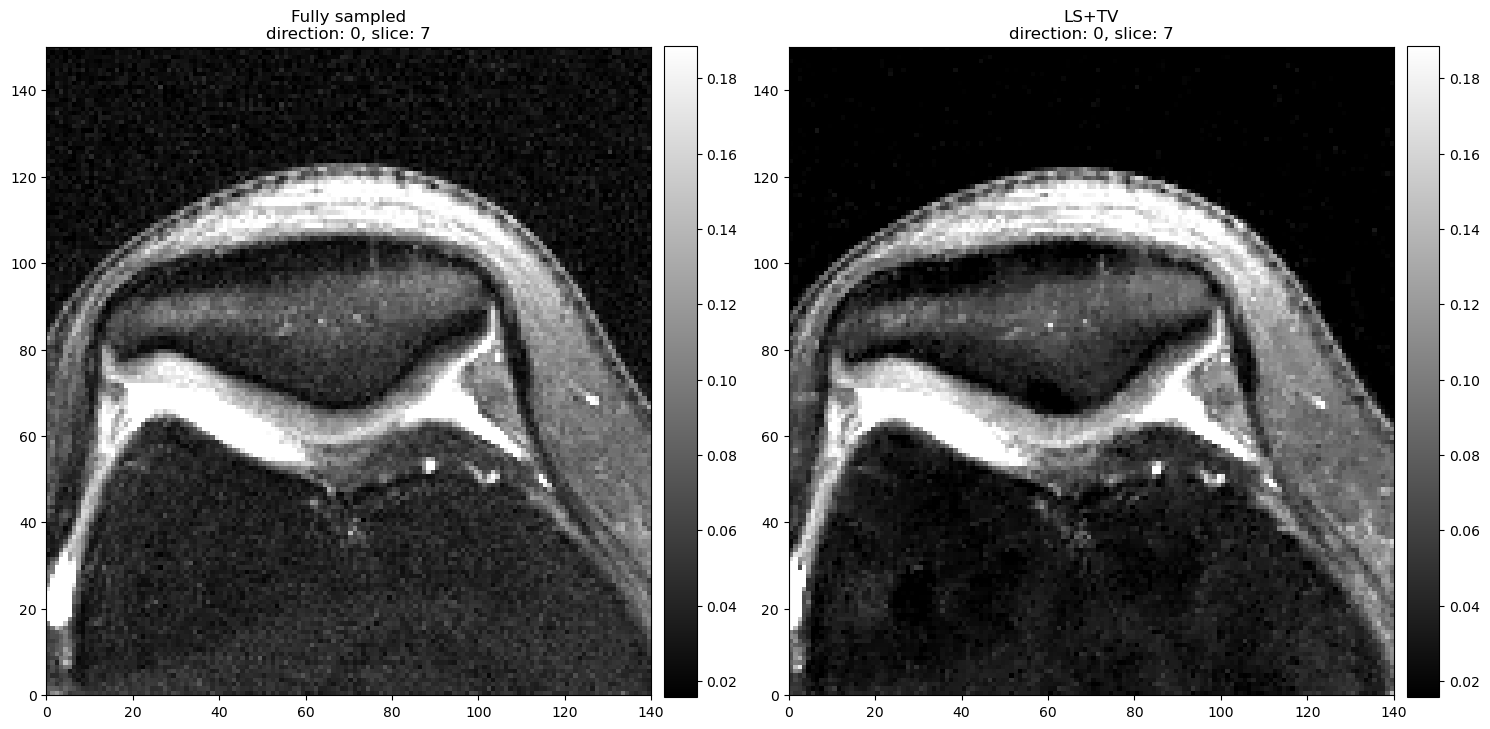

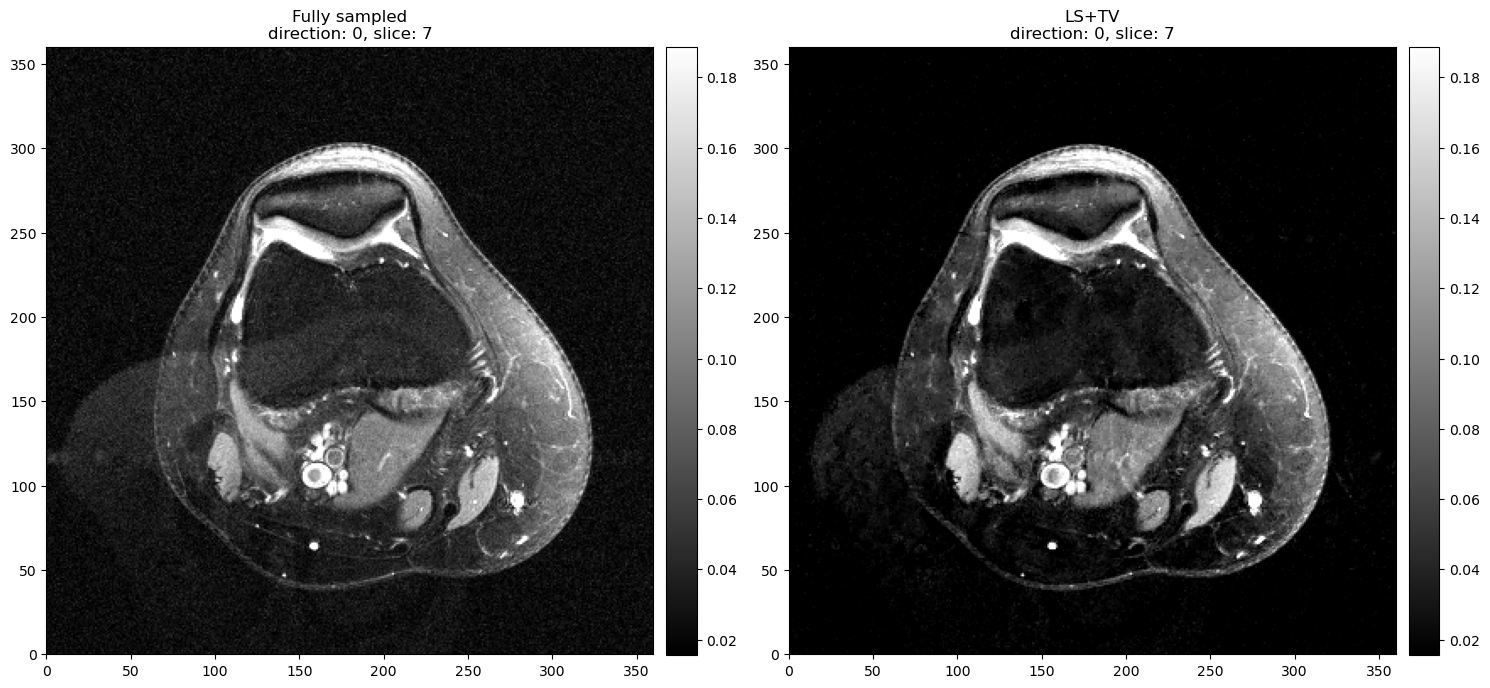

In [55]:
# ER rotate images
tv_recon_rotated = np.rot90(tv_recon, axes=(2, 1))

show2D([el[:,250:400, 180:320] for el in [fn_recon_rotated, tv_recon_rotated]],
       title=['Fully sampled', 'LS+TV'],
       slice_list=(0, 7), 
       fix_range=(np.percentile(fn_recon, 5), np.percentile(fn_recon, 99)),
      num_cols=2)

show2D([el[:,70:430, 70:430] for el in [fn_recon_rotated, tv_recon_rotated]],
       title=['Fully sampled', 'LS+TV'],
       slice_list=(0, 7), 
       fix_range=(np.percentile(fn_recon, 5), np.percentile(fn_recon, 99)),
      num_cols=2)

In [64]:
w = WaveletOperator(x_init, wname="bior4.4", level=1)
R_W = FunctionOfAbs(
    L1Sparsity(w)
)

/opt/conda/lib/python3.12/site-packages/cil/optimisation/functions/L1Sparsity.py:54: UserWarning: Invalid operator: `<cil.optimisation.operators.WaveletOperator.WaveletOperator object at 0x7f4fc038a3c0>`. L1Sparsity is properly defined only for orthogonal operators!
  warnings.warn(


In [68]:

x_init.geometry = x_init
algo_w = FISTA(x_init, f=f, g=R_W)
algo_w.run(10)


AttributeError: 'ImageData' object has no attribute 'geometry'

In [ ]:
np.save??

In [27]:
# Import algorithms, operators and functions from CIL optimisation module
from cil.optimisation.algorithms import GD, FISTA, PDHG
from cil.optimisation.operators import BlockOperator, GradientOperator,\
                                       GradientOperator
from cil.optimisation.functions import IndicatorBox, MixedL21Norm, L2NormSquared, \
                                       BlockFunction, L1Norm, LeastSquares, \
                                       OperatorCompositionFunction, TotalVariation, Function

# Import CIL Processors for preprocessing
from cil.processors import CentreOfRotationCorrector, Slicer, TransmissionAbsorptionConverter

# Import CIL display function
from cil.utilities.display import show2D

# Import from CIL ASTRA plugin
from cil.plugins.astra import ProjectionOperator

# Import FBP from CIL recon class
from cil.recon import FBP

#Import Total Variation from the regularisation toolkit plugin
from cil.plugins.ccpi_regularisation.functions import FGP_TV

# All external imports
import matplotlib.pyplot as plt
import math
from time import time
import gc
import numpy as np

In [63]:
import torch

class DenoiserProximal(Function):
    """
    DenoiserProximal is a custom CIL function that, when evaluated (__call__), returns 0. 
    It implements a proximal operator via a torch-based denoiser. When the
    proximal() method is called, the input CIL data container is converted into a PyTorch
    tensor, processed with the denoiser  using the specified noise level (tau), and then
    wrapped back into a CIL data container.

    Parameters:
        denoiser: The torch-based denoiser which accepts an input tensor and a noise level.
        device: The torch device (e.g., 'cuda' or 'cpu') on which the denoiser runs.
    """

    def __init__(self, denoiser, device='cuda'):
        self.device = torch.device(device)
        self.denoiser = denoiser 
        super(DenoiserProximal, self).__init__()

    def __call__(self, x):
        # This function merely returns 0 as its evaluation.
        return 0 

    def cil_to_torch(self, x):
        """
        Convert a CIL data container to a PyTorch tensor.

        This method extracts the 'array' attribute from the input CIL data container,
        moves the data to the designated device, and adjusts the tensor's shape by squeezing
        out the first dimension and adding a channel dimension. This reshaped tensor is then
        ready to be passed to the denoiser denoiser.

        Parameters:
            x: A CIL data container with an 'array' attribute containing the data.

        Returns:
            torch.Tensor: A PyTorch tensor formatted for the denoiser denoiser.
        """
        return (torch.tensor(x.array, device=self.device)
                .squeeze(0).unsqueeze(1))
    
    def torch_to_cil(self, x_tens, out):
        """
        Convert a PyTorch tensor to a CIL data container.

        After the denoiser processes the input, this method converts the resulting PyTorch tensor
        back into the format expected by a CIL data container. It performs a reverse of the shaping operations
        applied in cil_to_torch (i.e., removing the channel dimension and adding back the batch dimension)
        and updates the 'array' attribute of the output container.

        Parameters:
            x_tens (torch.Tensor): The processed tensor from the denoiser.
            out: A pre-allocated CIL data container to store the final output data.
        """
        out.array[:] = (x_tens.squeeze(1).unsqueeze(0)
                        .detach().cpu().numpy())
            
    def proximal(self, x, tau, out=None):
        """
        Apply the proximal operator via a torch-based denoiser to a CIL data container.

        This method implements the proximal step by first converting the input CIL data container
        to a PyTorch tensor using cil_to_torch. The tensor is then passed to the denoiser along
        with the provided noise level 'tau'. The output tensor is converted back into a CIL data container using
        torch_to_cil. If no output container is provided (i.e., out is None), a new container is allocated
        based on the geometry of x.

        Parameters:
            x: The input CIL data container to be processed.
            tau (float): A scalar noise level parameter passed to the denoiser.
            out: (Optional) A pre-allocated CIL data container for returning the result. If not provided,
                 a new container is allocated.

        Returns:
            A CIL data container containing the denoiser-processed data.
        """
        if out is None: 
            out = x.geometry.allocate(None)

        with torch.no_grad():
            x_torch = self.cil_to_torch(x)
            x_torch = self.denoiser(x_torch, tau)
            self.torch_to_cil(x_torch, out)
        return out 
        

In [65]:
import deepinv
import torch

In [61]:
denoiser = deepinv.models.DRUNet(in_channels=1, out_channels=1, pretrained='download')
regulariser = DenoiserProximal(denoiser)

In [64]:
# AcquisitionModel E and starting point (x_init) were already set up above
E = AcquisitionModel(acqs=acq_data_ai, imgs=x_inverse)
E.set_coil_sensitivity_maps(csm)
x_init = x_inverse.clone()

# Define our objective/loss function as least squares between Ex and y
loss_fn = LeastSquares(E, acq_data_ai, c=1)

lamb = 0.5   # regularisation parameter

regulariser = lamb*DenoiserProximal(denoiser=denoiser)


In [62]:

myFISTADRUNet2D = FISTA(f = loss_fn, 
                  g = regulariser, 
                  initial = x_init.fill(0.0),
                  update_objective_interval = 10)



TV_denoised_image = regulariser.proximal(recon15, 1)
denoised_image= regulariser.proximal(recon15, 1)
show2D([recon15, TV_denoised_image, denoised_image  ], title=['FDK', 'TV denoised image', 'DnCNN denoised image'],
     slice_list=('vertical',sz), cmap='inferno', fix_range=(ca1,ca2), origin='upper-left', num_cols=3, size=(12,36) );


AttributeError: 'DenoiserProximal' object has no attribute 'shape'